##### Author: Pablo Iañez Picazo
##### Biomedical Data Science lab

In [30]:
# Load all the necessary libraries
from glob import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

# Supress all warnings (bcoz they're quite annoying)
import warnings

warnings.filterwarnings("ignore")

from hsc_spatial_stats import *

In [31]:
# Set visual properties for plotting
sns.set(rc={"figure.figsize": (6, 4)})
sns.set_style("whitegrid")
sns.color_palette("colorblind")

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [34]:
# Set up some parameters
res = 0.1
folder = "data"
conditions = [
    "young",
    "old",
    "treated_RhoAi",
    "compressed_8um",
    "compressed_5um",
    "compressed_3um",
]

palette = {
    "Young": (0.00392, 0.45098, 0.69803),
    "Aged": (0.00784, 0.61960, 0.45098),
    "Aged + Ri": (0.8, 0.47058, 0.73725),
    "8μm": (0.79215, 0.56862, 0.38039),
    "5μm": (0.87058, 0.56078, 0.01960),
    "3μm": (0.83529, 0.36862, 0.0),
}

In [33]:
# Prepare a couple of utils functions to fix labels and plotting aesthetics
def reduce_xticks(xticklabels):
    for i, label in enumerate(xticklabels):
        if i % 5 == 0:
            label.set_visible(True)
        else:
            label.set_visible(False)

young


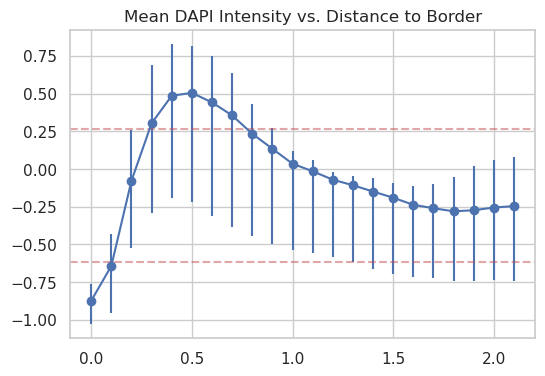

old


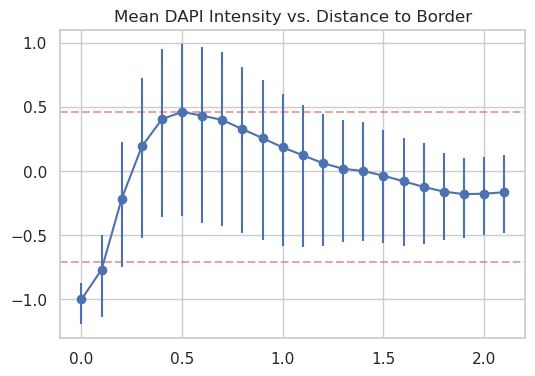

treated_RhoAi


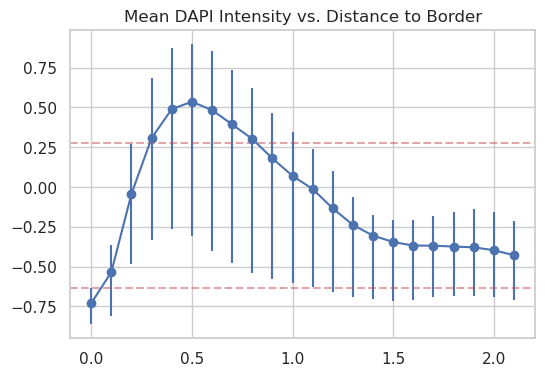

compressed_8um


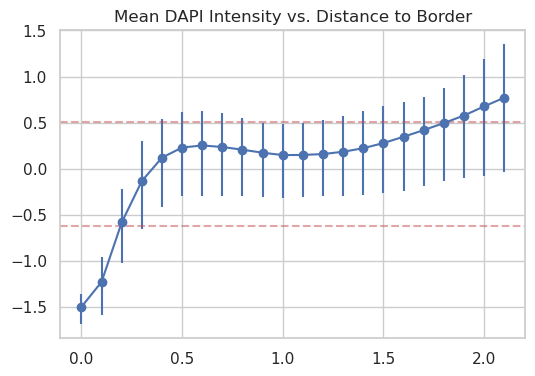

compressed_5um


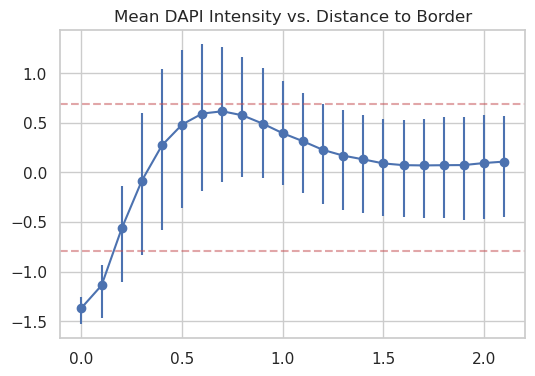

compressed_3um


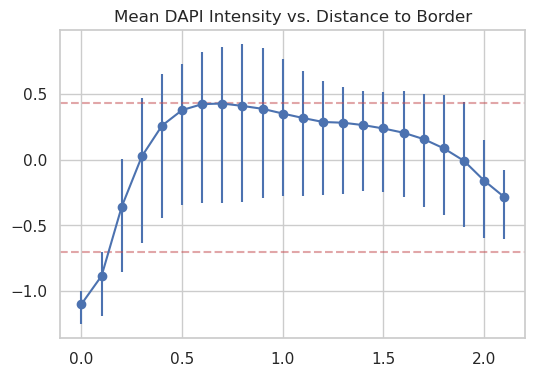

In [35]:
nuc_df = pd.DataFrame()

for cond in conditions:
    # Lists .npz files within containing folder with a given prefix
    npz_ims = glob(f"{folder}/res_{res}_z_score_norm/{cond}/*.npz")
    print(cond)

    for i, npz in enumerate(npz_ims[:1]):
        image = np.load(npz)
        nuc_mask = image["seg"].astype(int)
        im = image["dapi"]

        # Rotate the image and convert to XYZ coordenates
        im, nuc_mask = from_zxy_to_xyz([im, nuc_mask])
        # ---------gets distance near nuclear border
        dist2bord = distance_transform_edt(nuc_mask)

        # --------plots mean intensity vs. distance continuously
        plot_intensity_profile_3D(im, nuc_mask, dist2bord, res, max_dist=22)

In [36]:
nuc_df = pd.DataFrame()

# With the round cells we can have more accurate information because the
# confined ones are not that big and does not reach the same distances
condition2distance = {
    "young": 17,
    "old": 17,
    "treated_RhoAi": 17,
    "compressed_8um": 17,
    "compressed_5um": 15,
    "compressed_3um": 13,
}

for cond in conditions:
    # Lists .npz files within containing folder with a given prefix
    npz_ims = glob(f"{folder}/res_{res}_z_score_norm/{cond}/*.npz")
    print(cond)

    for i, npz in enumerate(npz_ims):
        image = np.load(npz)
        nuc_mask = image["seg"].astype(int)
        im = image["dapi"]

        # Rotate the image and convert to XYZ coordenates
        im, nuc_mask = from_zxy_to_xyz([im, nuc_mask])
        # ---------gets distance near nuclear border
        dist2bord = distance_transform_edt(nuc_mask)

        # To solve the problem with intensities having different array lengths
        df = get_intensity_by_distance(
            im, nuc_mask, dist2bord, res, max_dist=condition2distance[cond]
        )
        df["condition"] = cond
        nuc_df = pd.concat([nuc_df, df])

    print(i)

nuc_df = fix_labels(nuc_df)

young
175
old
145
treated_RhoAi
126
compressed_8um
18
compressed_5um
30
compressed_3um
25


In [37]:
# Check number of existing measures per distance
nuc_df.distance.value_counts()

0.0    525
0.5    525
0.1    525
0.7    525
0.6    525
0.8    525
0.4    525
0.3    525
0.2    525
0.9    524
1.0    523
1.1    523
1.2    519
1.3    499
1.4    495
1.5    468
1.6    468
Name: distance, dtype: int64

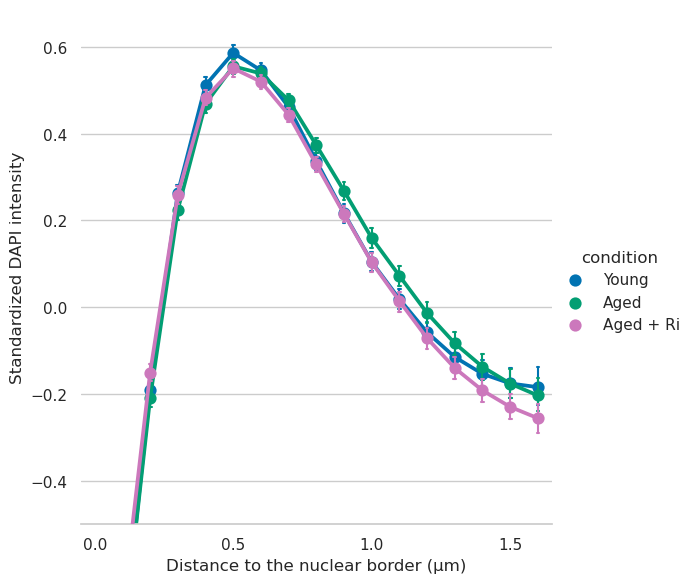

In [12]:
# Plot intensity vs distance profiles
my_df = nuc_df[nuc_df["condition"].isin(["Young", "Aged", "Aged + Ri"])]
g = sns.catplot(
    data=my_df,
    x="distance",
    y="mean_int",
    hue="condition",
    capsize=0.1,
    errorbar="se",
    errwidth=1.5,
    palette=palette,
    kind="point",
    height=6,
)

g.set(ylim=(-0.5, None))
reduce_xticks(plt.gca().get_xticklabels())
plt.xlabel("Distance to the nuclear border (μm)")
plt.ylabel("Standardized DAPI intensity")
sns.despine(left=True)
plt.show()

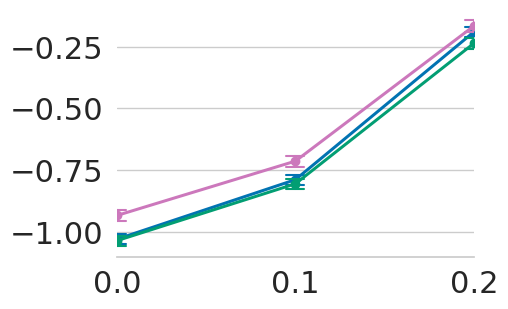

In [38]:
# Plot intensity vs distance profiles zooming in the range 0 - 0.2
my_df = nuc_df[nuc_df["condition"].isin(["Young", "Aged", "Aged + Ri"])]

sns.set(font_scale=2, rc={"lines.linewidth": 1.2})
sns.set_style("whitegrid")
g = sns.catplot(
    data=my_df,
    x="distance",
    y="mean_int",
    hue="condition",
    capsize=0.1,
    errorbar="se",
    errwidth=1.5,
    palette=palette,
    kind="point",
    height=4,
    aspect=1.5,
)
g.set(ylim=(-1.1, -0.1), xlim=(0, 2))
g.set(xlabel=None, ylabel=None)
g._legend.remove()
# reduce_xticks(plt.gca().get_xticklabels())
sns.despine(left=True)
plt.show()

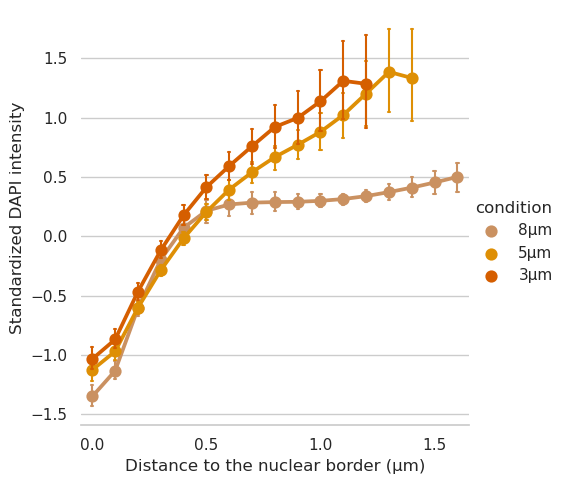

In [39]:
# Reset figure aesthetics that were changed before
sns.reset_orig()
sns.set(font_scale=1)
sns.set_style("whitegrid")

# Plot intensity vs distance profiles
my_df = nuc_df[nuc_df["condition"].isin(["8μm", "5μm", "3μm"])]
g = sns.catplot(
    data=my_df,
    x="distance",
    y="mean_int",
    hue="condition",
    capsize=0.1,
    errorbar="se",
    errwidth=1.5,
    palette=palette,
    kind="point",
    height=5,
)
reduce_xticks(plt.gca().get_xticklabels())
plt.xlabel("Distance to the nuclear border (μm)")
plt.ylabel("Standardized DAPI intensity")
sns.despine(left=True)
plt.show()

In [41]:
nuc_df = pd.DataFrame()
index = 1

for cond in conditions:
    # Lists .npz files within containing folder with a given prefix
    npz_ims = glob(f"{folder}/res_{res}_z_score_norm/{cond}/*.npz")
    print(cond)

    for i, npz in enumerate(npz_ims):
        image = np.load(npz)
        nuc_mask = image["seg"].astype(int)
        im = image["dapi"]

        # Rotate the image and convert to XYZ coordenates
        im, nuc_mask = from_zxy_to_xyz([im, nuc_mask])
        # ---------gets distance near nuclear border
        dist2bord = distance_transform_edt(nuc_mask)

        # Measure intensity in the distance interval specified in the tupples
        for interval in [(0, 5), (5, 10), (10, 15), (15, 20)]:
            imin, imax = interval

            df = pd.DataFrame(
                {
                    "intensity": [
                        get_intensity_in_distance(
                            im, nuc_mask, dist2bord, distance_range=interval
                        )
                    ],
                    "interval": f"{imin*res} - {imax*res}",
                    "condition": cond,
                    "nucleus_index": index,
                }
            )

            nuc_df = pd.concat([nuc_df, df])
        index += 1

nuc_df = fix_labels(nuc_df)

young
old
treated_RhoAi
compressed_8um
compressed_5um
compressed_3um


In [42]:
nuc_df

,intensity,interval,condition,nucleus_index
0,-0.205233,0.0 - 0.5,Young,1
0,0.384372,0.5 - 1.0,Young,1
0,-0.028514,1.0 - 1.5,Young,1
0,-0.227111,1.5 - 2.0,Young,1
0,-0.671657,0.0 - 0.5,Young,2
...,...,...,...,...
0,NaN,1.5 - 2.0,3μm,524
0,-0.303796,0.0 - 0.5,3μm,525
0,-0.126586,0.5 - 1.0,3μm,525
0,0.090598,1.0 - 1.5,3μm,525


p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.5 - 1.0_5μm vs. 0.5 - 1.0_3μm: Mann-Whitney-Wilcoxon test two-sided, P_val:8.400e-03 U_stat=2.380e+02
1.0 - 1.5_8μm vs. 1.0 - 1.5_5μm: Mann-Whitney-Wilcoxon test two-sided, P_val:9.117e-06 U_stat=7.200e+01
1.0 - 1.5_5μm vs. 1.0 - 1.5_3μm: Mann-Whitney-Wilcoxon test two-sided, P_val:1.942e-01 U_stat=2.950e+02
0.0 - 0.5_8μm vs. 0.0 - 0.5_5μm: Mann-Whitney-Wilcoxon test two-sided, P_val:4.148e-02 U_stat=1.920e+02
0.0 - 0.5_5μm vs. 0.0 - 0.5_3μm: Mann-Whitney-Wilcoxon test two-sided, P_val:1.812e-02 U_stat=2.550e+02
0.5 - 1.0_8μm vs. 0.5 - 1.0_5μm: Mann-Whitney-Wilcoxon test two-sided, P_val:2.084e-03 U_stat=1.400e+02
1.0 - 1.5_8μm vs. 1.0 - 1.5_3μm: Mann-Whitney-Wilcoxon test two-sided, P_val:8.667e-05 U_stat=6.700e+01
0.5 - 1.0_8μm vs. 0.5 - 1.0_3μm: Mann-Whitney-Wilcoxon test two-sided, P_val:9.816e-05 U_st

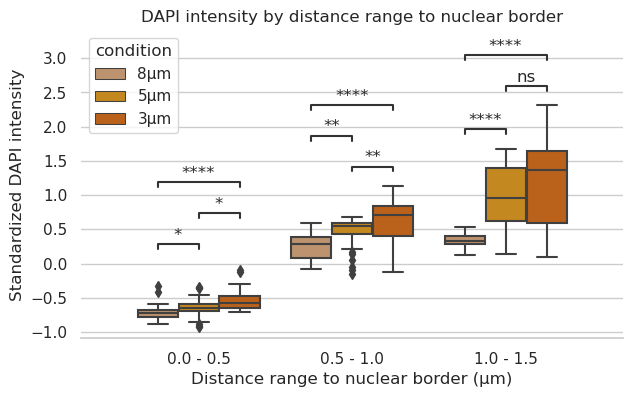

In [43]:
sns.set(rc={"figure.figsize": (7, 4)})
sns.set_style("whitegrid")

# Prepare pairs for statistical significance
pairs = []
for r in ("0.0 - 0.5", "0.5 - 1.0", "1.0 - 1.5"):
    pairs.extend(
        [
            ((r, "8μm"), (r, "5μm")),
            ((r, "5μm"), (r, "3μm")),
            ((r, "8μm"), (r, "3μm")),
        ]
    )

# Plot boxplot of intensity by distance interval
my_df = nuc_df[nuc_df["condition"].isin(["8μm", "5μm", "3μm"])]
my_df = my_df[my_df["interval"].isin(["0.0 - 0.5", "0.5 - 1.0", "1.0 - 1.5"])]
b = sns.boxplot(
    data=my_df, x="interval", y="intensity", hue="condition", palette=palette
)

# Plot statistical significance on top
annotator = Annotator(
    ax=b, data=my_df, x="interval", y="intensity", hue="condition", pairs=pairs
)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside")
annotator.apply_and_annotate()

# Figure aesthetic parameters
plt.title("DAPI intensity by distance range to nuclear border")
plt.xlabel("Distance range to nuclear border (μm)")
plt.ylabel("Standardized DAPI intensity")
sns.despine(left=True)
plt.show()

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.5 - 1.0_Aged vs. 0.5 - 1.0_Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:1.222e-02 U_stat=1.090e+04
1.0 - 1.5_Young vs. 1.0 - 1.5_Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:1.369e-06 U_stat=8.831e+03
1.0 - 1.5_Aged vs. 1.0 - 1.5_Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:7.936e-06 U_stat=1.218e+04
1.5 - 2.0_Young vs. 1.5 - 2.0_Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:5.251e-01 U_stat=1.232e+04
1.5 - 2.0_Aged vs. 1.5 - 2.0_Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:3.439e-02 U_stat=1.065e+04
0.0 - 0.5_Young vs. 0.0 - 0.5_Aged: Mann-Whitney-Wilcoxon test two-sided, P_val:1.956e-03 U_stat=1.542e+04
0.0 - 0.5_Aged vs. 0.0 - 0.5_Aged + Ri: Mann-Whitney-Wilcoxon test two-sided, P_val:9.274e-07 U_stat=6.078e+03
0.5 - 1.0_Young vs. 0.5 - 1.0_Aged: Mann-Whitney-Wilco

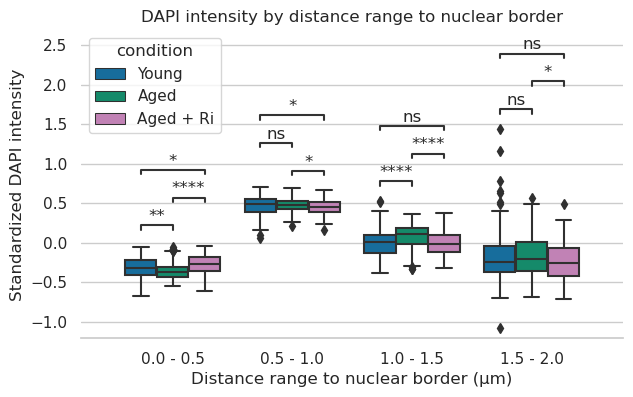

In [44]:
my_df = nuc_df[nuc_df["condition"].isin(["Young", "Aged", "Aged + Ri"])]

# Prepare pairs for statistical significance
pairs = []
for r in ("0.0 - 0.5", "0.5 - 1.0", "1.0 - 1.5", "1.5 - 2.0"):
    pairs.extend(
        [
            ((r, "Young"), (r, "Aged")),
            ((r, "Young"), (r, "Aged + Ri")),
            ((r, "Aged"), (r, "Aged + Ri")),
        ]
    )

# Plot boxplot of intensity by distance interval
b = sns.boxplot(
    data=my_df, x="interval", y="intensity", hue="condition", palette=palette
)

# Plot statistical significance on top
annotator = Annotator(
    ax=b, data=my_df, x="interval", y="intensity", hue="condition", pairs=pairs
)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside")
annotator.apply_and_annotate()
plt.title("DAPI intensity by distance range to nuclear border")
plt.xlabel("Distance range to nuclear border (μm)")
plt.ylabel("Standardized DAPI intensity")
sns.despine(left=True)
plt.show()